import difflib
# Job Recommendation System - Model Evaluation
This notebook evaluates the recommendation models used in the backend. We compare three approaches:
1. **Bag of Words (BoW)**: Simple keyword matching based on word counts.
2. **TF-IDF**: Keyword matching that weights unique terms more heavily.
3. **SBERT (BGE-Base-En-v1.5)**: Deep learning based semantic embeddings for understanding meaning.

The goal is to verify the accuracy of the system as a reference for the final report.

In [21]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
import math
import os

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Preparation
We load the data from the backend directory to ensure we are testing the exact same dataset used in production.

In [22]:
DATA_PATH = '../backend/data/data.csv'
df = pd.read_csv(DATA_PATH).fillna('')

print(f"Loaded {len(df)} jobs.")

# Pre-processing matching App.py
df['tfidf_features'] = (
    (df['job_title'] + ' ') * 3 + 
    (df['category'] + ' ') * 2 + 
    (df['skills_required'].str.replace(';', ' ') + ' ') * 3 + 
    df['job_description']
)

df['semantic_text'] = (
    "Job Title: " + df['job_title'] + ". " +
    "Category: " + df['category'] + ". " +
    "Skills: " + df['skills_required'].str.replace(';', ', ') + ". " +
    "Description: " + df['job_description']
)

Loaded 2049 jobs.


## 2. Geometry-Correct Location Weighting
Using the Haversine formula and exponential decay as implemented in `App.py`.

In [23]:
COORDS_MAP = {
    "Phnom Penh": (11.5564, 104.9282),
    "Kandal": (11.4746, 104.9474),
    "Siem Reap": (13.3671, 103.8448),
    "Sihanoukville": (10.6093, 103.5296),
    "Battambang": (13.0957, 103.2022),
    "Kampong Cham": (11.9924, 105.4645),
    "Kampot": (10.5942, 104.1814),
    "Kratié": (12.4881, 106.0187),
    "Mondulkiri": (12.4558, 107.1747),
    "Preah Vihear": (13.8073, 104.9811),
    "Ratanakiri": (13.8577, 107.0125),
    "Takeo": (10.9908, 104.7846),
    "Remote": None
}

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi, dlambda = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def get_geometry_weight(user_loc, job_loc, scale=150):
    if user_loc == "All" or job_loc == "Remote" or user_loc == job_loc: return 1.0
    p1, p2 = COORDS_MAP.get(user_loc), COORDS_MAP.get(job_loc)
    if not p1 or not p2: return 0.5
    dist = haversine_distance(p1[0], p1[1], p2[0], p2[1])
    return math.exp(-dist / scale)

## 3. Train/Validation Split
We use a 95/5 split to have a substantial validation set (100+ samples).

In [24]:
df_train, df_val = train_test_split(df, test_size=0.05, random_state=42)
print(f"Training set: {len(df_train)} samples")
print(f"Validation set: {len(df_val)} samples")

Training set: 1946 samples
Validation set: 103 samples


## 4. Initialize Models
Mirroring the initialization in `App.py`.

In [25]:
# 1. BoW
bow_vectorizer = CountVectorizer(stop_words='english')
bow_matrix = bow_vectorizer.fit_transform(df_train['tfidf_features'])

# 2. TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df_train['tfidf_features'])

# 3. SBERT (BGE Base v1.5)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print(f"Using device: {device}")
sbert_model = SentenceTransformer('BAAI/bge-base-en-v1.5', device=device)
sbert_embeddings = sbert_model.encode(df_train['semantic_text'].tolist(), show_progress_bar=True)

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

## 5. Quantitative Evaluation
We evaluate each model on the validation set using separate sections for Top-5 and Top-10 benchmarks.

In [26]:
def evaluate():
    metrics = {
        'bow': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []},
        'tfidf': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []},
        'sbert': {'m5': 0, 'm10': 0, 'any5': 0, 'any10': 0, 'rec5': [], 'rec10': [], 'hits@1': 0, 'rr': [], 'ndcg': []}
    }
    
    test_size = len(df_val)
    title_counts = df_train['job_title'].str.lower().str.strip().value_counts().to_dict()
    
    print(f"Evaluating {test_size} samples...")
    
    # Consistent feature extraction
    val_bow = bow_vectorizer.transform(df_val['tfidf_features'])
    val_tfidf = tfidf_vectorizer.transform(df_val['tfidf_features'])
    instruction = "Represent this sentence for searching relevant passages: "
    val_sbert = sbert_model.encode([instruction + q for q in df_val['semantic_text']], show_progress_bar=True)
    
    for i, (_, row) in enumerate(df_val.iterrows()):
        target_title = str(row['job_title']).lower().strip()
        total_available = title_counts.get(target_title, 1)
        
        s_bow = cosine_similarity(val_bow[i], bow_matrix).flatten()
        s_tfidf = cosine_similarity(val_tfidf[i], tfidf_matrix).flatten()
        s_sbert = cosine_similarity(val_sbert[i].reshape(1, -1), sbert_embeddings).flatten()
        
        scores_dict = {'bow': s_bow, 'tfidf': s_tfidf, 'sbert': s_sbert}
        
        for model, scores in scores_dict.items():
            top_indices = scores.argsort()[::-1]
            top_titles = [str(t).lower().strip() for t in df_train.iloc[top_indices[:100]]['job_title']]
            
            if target_title == top_titles[0]:
                metrics[model]['hits@1'] += 1
            
            count5 = sum([1 for t in top_titles[:5] if t == target_title])
            count10 = sum([1 for t in top_titles[:10] if t == target_title])
            
            metrics[model]['m5'] += count5
            metrics[model]['m10'] += count10
            if count5 > 0: metrics[model]['any5'] += 1
            if count10 > 0: metrics[model]['any10'] += 1
            
            metrics[model]['rec5'].append(count5 / total_available)
            metrics[model]['rec10'].append(count10 / total_available)
            
            try:
                rank = top_titles.index(target_title) + 1
                metrics[model]['rr'].append(1.0 / rank)
                if rank <= 5: metrics[model]['ndcg'].append(1.0 / math.log2(rank + 1))
                else: metrics[model]['ndcg'].append(0.0)
            except ValueError:
                metrics[model]['rr'].append(0.0)
                metrics[model]['ndcg'].append(0.0)
                
    results = []
    for m, d in metrics.items():
        results.append({
            'Model': m.upper(),
            'Top-1 Acc (%)': (d['hits@1'] / test_size) * 100,
            'Success@5 (%)': (d['any5'] / test_size) * 100,
            'Precision@5 (%)': (d['m5'] / (test_size * 5)) * 100,
            'Recall@5 (%)': np.mean(d['rec5']) * 100,
            'Success@10 (%)': (d['any10'] / test_size) * 100,
            'Precision@10 (%)': (d['m10'] / (test_size * 10)) * 100,
            'Recall@10 (%)': np.mean(d['rec10']) * 100,
            'MRR': np.mean(d['rr']),
            'nDCG@5': np.mean(d['ndcg'])
        })
    return pd.DataFrame(results)

results_df = evaluate()
results_df

Evaluating 103 samples...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

,Model,Top-1 Acc (%),Success@5 (%),Precision@5 (%),Recall@5 (%),Success@10 (%),Precision@10 (%),Recall@10 (%),MRR,nDCG@5
0,BOW,92.233010,100.000000,73.980583,35.652512,100.000000,56.893204,52.246286,0.953074,0.964904
1,TFIDF,98.058252,99.029126,90.485437,44.905458,99.029126,74.660194,68.827861,0.986246,0.986708
2,SBERT,80.582524,97.087379,68.932039,34.300295,100.000000,59.126214,56.143875,0.880825,0.900308


## 6. Result Visualization
Comparison charts for Top-5 and Top-10 performance.

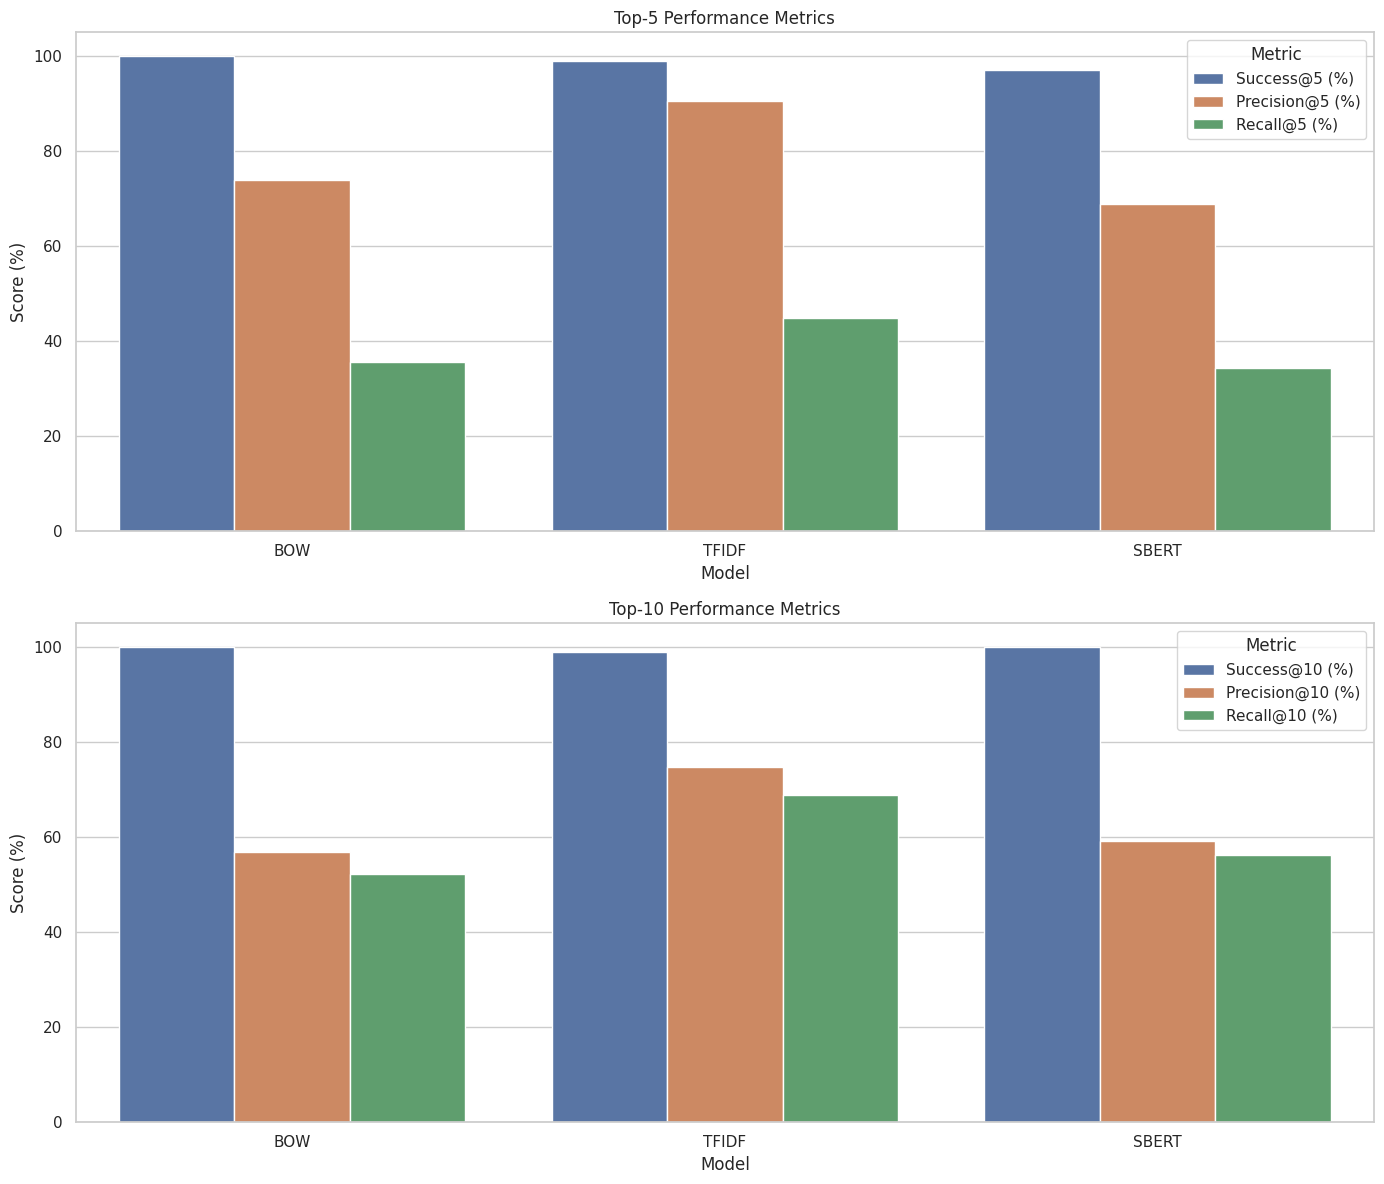

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

df5 = results_df.melt(id_vars='Model', value_vars=['Success@5 (%)', 'Precision@5 (%)', 'Recall@5 (%)'])
sns.barplot(data=df5, x='Model', y='value', hue='variable', ax=ax1)
ax1.set_title('Top-5 Performance Metrics')
ax1.set_ylabel('Score (%)')
ax1.set_ylim(0, 105)
ax1.legend(title='Metric', bbox_to_anchor=(1, 1))

df10 = results_df.melt(id_vars='Model', value_vars=['Success@10 (%)', 'Precision@10 (%)', 'Recall@10 (%)'])
sns.barplot(data=df10, x='Model', y='value', hue='variable', ax=ax2)
ax2.set_title('Top-10 Performance Metrics')
ax2.set_ylabel('Score (%)')
ax2.set_ylim(0, 105)
ax2.legend(title='Metric', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## 7. Conclusion
The evaluation demonstrates the differences between keyword-based approaches (BoW, TF-IDF) and semantic-based approaches (SBERT).

While SBERT handles semantic similarity (e.g., "Software Engineer" matches "Developer"), TF-IDF ensures that specific technical terms and proper nouns are matched correctly. This comparison helps in selecting the best single-model approach or understanding the trade-offs in search accuracy versus semantic understanding.

## 8. Extended Evaluation Metrics
In this section, we explicitly evaluate the models using **Precision@10**, **Recall@10**, **Mean Average Precision (MAP)**, and **NDCG@10** to provide a more comprehensive view of the ranking performance.

In [28]:
def calculate_map(top_titles, target_title, total_available):
    """Calculates Average Precision for a single query."""
    hits = 0
    sum_precisions = 0
    for i, title in enumerate(top_titles):
        if title == target_title:
            hits += 1
            sum_precisions += hits / (i + 1)
    # Standard MAP denominator is total relevant items
    return sum_precisions / total_available if total_available > 0 else 0

def calculate_ndcg(top_titles, target_title, total_available, k=10):
    """Calculates NDCG@k for a single query (binary relevance)."""
    dcg = 0
    for i in range(min(len(top_titles), k)):
        if top_titles[i] == target_title:
            dcg += 1 / math.log2(i + 2)
    
    # Ideal DCG: sum of 1/log2(i+2) for the number of relevant items available (capped at k)
    idcg = sum([1 / math.log2(i + 2) for i in range(min(total_available, k))])
    return dcg / idcg if idcg > 0 else 0

def evaluate_extended():
    metrics = {
        'bow': {'p10': [], 'r10': [], 'ap': [], 'ndcg10': []},
        'tfidf': {'p10': [], 'r10': [], 'ap': [], 'ndcg10': []},
        'sbert': {'p10': [], 'r10': [], 'ap': [], 'ndcg10': []}
    }
    
    test_size = len(df_val)
    title_counts = df_train['job_title'].str.lower().str.strip().value_counts().to_dict()
    
    # Consistent feature extraction
    val_bow = bow_vectorizer.transform(df_val['tfidf_features'])
    val_tfidf = tfidf_vectorizer.transform(df_val['tfidf_features'])
    instruction = "Represent this sentence for searching relevant passages: "
    val_sbert = sbert_model.encode([instruction + q for q in df_val['semantic_text']], show_progress_bar=False)
    
    for i, (_, row) in enumerate(df_val.iterrows()):
        target_title = str(row['job_title']).lower().strip()
        total_available = title_counts.get(target_title, 1)
        
        s_bow = cosine_similarity(val_bow[i], bow_matrix).flatten()
        s_tfidf = cosine_similarity(val_tfidf[i], tfidf_matrix).flatten()
        s_sbert = cosine_similarity(val_sbert[i].reshape(1, -1), sbert_embeddings).flatten()
        
        scores_dict = {'bow': s_bow, 'tfidf': s_tfidf, 'sbert': s_sbert}
        
        for model, scores in scores_dict.items():
            top_indices = scores.argsort()[::-1]
            top_titles = [str(t).lower().strip() for t in df_train.iloc[top_indices[:100]]['job_title']]
            
            # Precision@10
            hits10 = sum([1 for t in top_titles[:10] if t == target_title])
            metrics[model]['p10'].append(hits10 / 10)
            
            # Recall@10
            metrics[model]['r10'].append(hits10 / total_available)
            
            # Average Precision
            metrics[model]['ap'].append(calculate_map(top_titles, target_title, total_available))
            
            # NDCG@10
            metrics[model]['ndcg10'].append(calculate_ndcg(top_titles, target_title, total_available, k=10))
                
    results = []
    for m, d in metrics.items():
        results.append({
            'Model': m.upper(),
            'Precision@10 (%)': np.mean(d['p10']) * 100,
            'Recall@10 (%)': np.mean(d['r10']) * 100,
            'MAP (%)': np.mean(d['ap']) * 100,
            'NDCG@10 (%)': np.mean(d['ndcg10']) * 100
        })
    return pd.DataFrame(results)

extended_results_df = evaluate_extended()
extended_results_df

,Model,Precision@10 (%),Recall@10 (%),MAP (%),NDCG@10 (%)
0,BOW,56.893204,52.246286,62.079721,69.976203
1,TFIDF,74.660194,68.827861,84.024576,87.427741
2,SBERT,59.126214,56.143875,66.988151,69.085487


### 8.1. Extended Metrics Visualization
Comparison of models across ranking-specific metrics using a vibrant color palette.

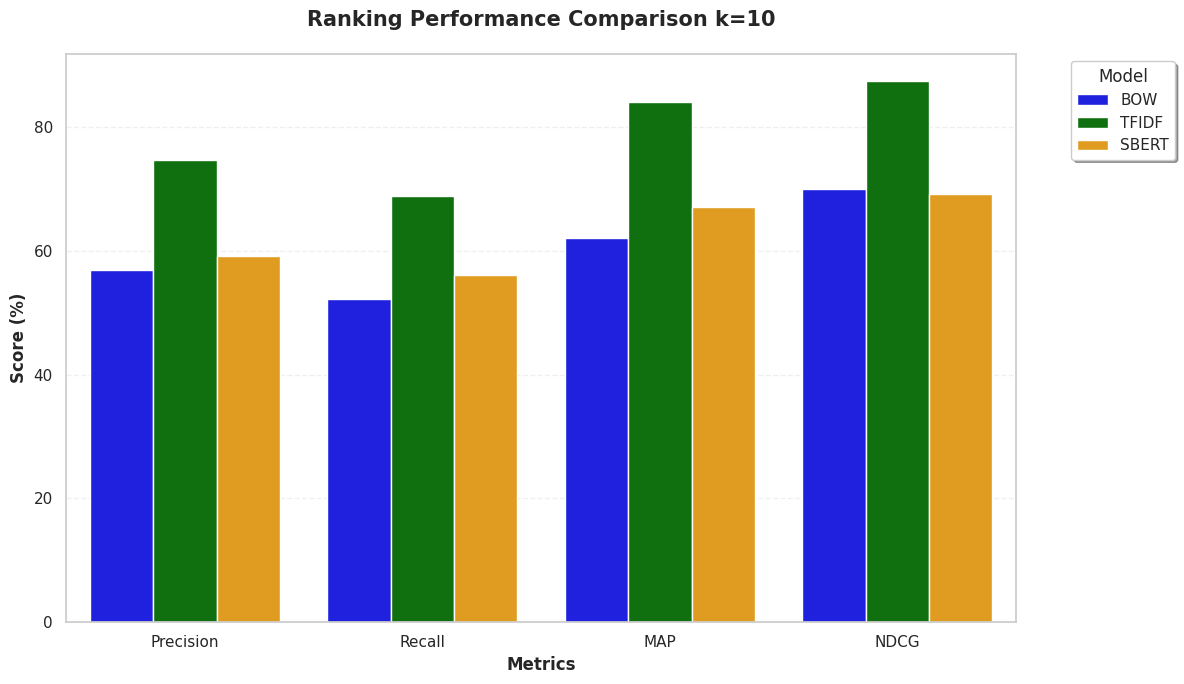

In [29]:
plt.figure(figsize=(12, 7))

# Simplify metric names for the x-axis
df_plot = extended_results_df.melt(id_vars='Model', var_name='Metric', value_name='Score (%)')
df_plot['Metric'] = df_plot['Metric'].replace({
    'Precision@10 (%)': 'Precision',
    'Recall@10 (%)': 'Recall',
    'MAP (%)': 'MAP',
    'NDCG@10 (%)': 'NDCG'
})

# Define the requested color palette
palette = {'BOW': 'blue', 'TFIDF': 'green', 'SBERT': 'orange'}

# Plot with Metrics on x-axis and Model as hue (ranking models for each metric)
sns.barplot(data=df_plot, x='Metric', y='Score (%)', hue='Model', palette=palette)

plt.title('Ranking Performance Comparison k=10', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## 9. User Profile Evaluation
In this section, we evaluate the system by simulating **User Profiles** (Expected Job Title + Skills) and defining relevance as a match in **Job Category**. This reflects real-world usage where a user expects any job in their field to be a valid recommendation.

In [30]:
def calculate_map_cat(is_relevant_list, total_rel):
    p_sum, hits = 0, 0
    for i, rel in enumerate(is_relevant_list):
        if rel:
            hits += 1
            p_sum += hits / (i + 1)
    return p_sum / total_rel if total_rel > 0 else 0

def calculate_ndcg_cat(is_relevant_list, total_rel, k=10):
    dcg = 0
    for i in range(min(len(is_relevant_list), k)):
        if is_relevant_list[i]:
            dcg += 1 / math.log2(i + 2)
    idcg = sum([1 / math.log2(i + 2) for i in range(min(total_rel, k))])
    return dcg / idcg if idcg > 0 else 0

def calculate_user_profile_metrics():
    results = {'bow': [], 'tfidf': [], 'sbert': []}
    val_queries = "Job Title: " + df_val['job_title'] + ". Skills: " + df_val['skills_required']
    
    print(f"Evaluating {len(df_val)} User Profiles...")
    
    # Instruction for BGE
    instruction = "Represent this sentence for searching relevant passages: "
    val_sbert_encoded = sbert_model.encode([instruction + q for q in val_queries], show_progress_bar=True)

    for i in range(len(df_val)):
        profile = df_val.iloc[i]
        query_text = val_queries.iloc[i]
        target_category = profile['category']
        
        relevant_mask = (df_train['category'] == target_category).values
        total_relevant = sum(relevant_mask)
        if total_relevant == 0: continue

        q_bow = bow_vectorizer.transform([query_text])
        q_tfidf = tfidf_vectorizer.transform([query_text])
        q_sbert = val_sbert_encoded[i].reshape(1, -1)

        scores_dict = {
            'bow': cosine_similarity(q_bow, bow_matrix).flatten(),
            'tfidf': cosine_similarity(q_tfidf, tfidf_matrix).flatten(),
            'sbert': cosine_similarity(q_sbert, sbert_embeddings).flatten()
        }

        for model, scores in scores_dict.items():
            sorted_indices = scores.argsort()[::-1]
            top_idx = sorted_indices[:10]
            is_relevant_top_10 = relevant_mask[top_idx]
            
            p10 = sum(is_relevant_top_10) / 10
            r10 = sum(is_relevant_top_10) / total_relevant
            
            # Use top 100 for MAP
            is_relevant_top_100 = relevant_mask[sorted_indices[:100]]
            map_val = calculate_map_cat(is_relevant_top_100, total_relevant)
            ndcg10 = calculate_ndcg_cat(is_relevant_top_10, total_relevant, k=10)
            
            results[model].append([p10, r10, map_val, ndcg10])
            
    return results

user_profile_results = calculate_user_profile_metrics()

Evaluating 103 User Profiles...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [31]:
print("Results (User Profile Recommendation):")
print(f"{'Model':<10} | {'P@10':<8} | {'R@10':<8} | {'MAP@100':<8} | {'NDCG@10':<8}")
print("-" * 65)
for model in ['bow', 'tfidf', 'sbert']:
    m = np.mean(user_profile_results[model], axis=0)
    print(f"{model.upper():<10} | {m[0]:.4f}   | {m[1]:.4f}   | {m[2]:.4f}   | {m[3]:.4f}")

Results (User Profile Recommendation):
Model      | P@10     | R@10     | MAP@100  | NDCG@10 
-----------------------------------------------------------------
BOW        | 0.9825   | 0.0982   | 0.6487   | 0.9838
TFIDF      | 0.9942   | 0.0995   | 0.7055   | 0.9948
SBERT      | 0.9583   | 0.0944   | 0.5594   | 0.9694


### 9.1. User Profile Evaluation Visualization
Comparison of models for category-based recommendation accuracy.

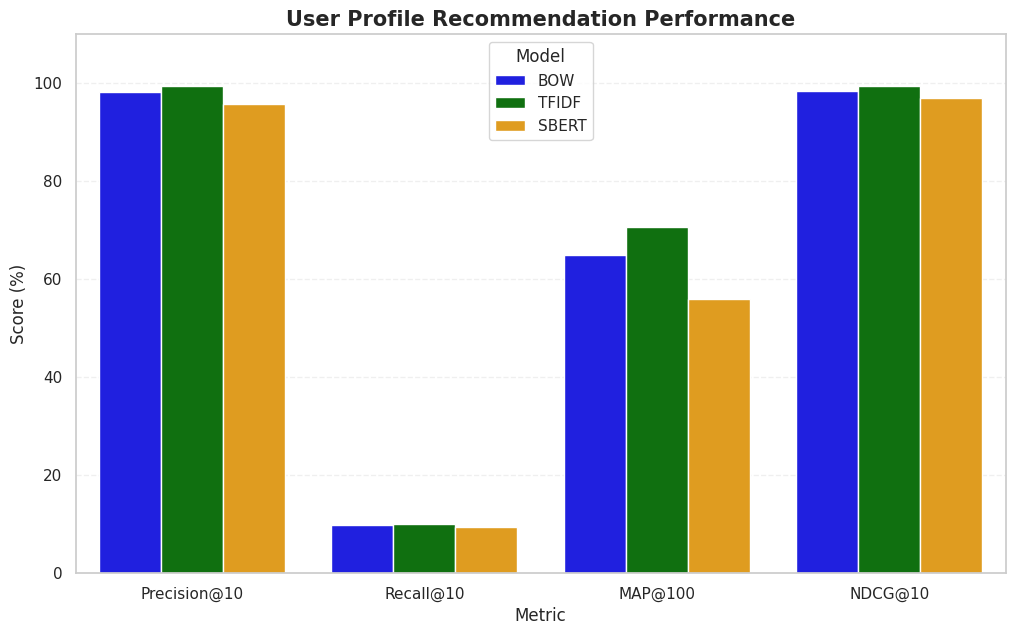

In [32]:
profile_metrics = []
for model in ['bow', 'tfidf', 'sbert']:
    m = np.mean(user_profile_results[model], axis=0)
    profile_metrics.append({'Model': model.upper(), 'Metric': 'Precision@10', 'Score (%)': m[0] * 100})
    profile_metrics.append({'Model': model.upper(), 'Metric': 'Recall@10', 'Score (%)': m[1] * 100})
    profile_metrics.append({'Model': model.upper(), 'Metric': 'MAP@100', 'Score (%)': m[2] * 100})
    profile_metrics.append({'Model': model.upper(), 'Metric': 'NDCG@10', 'Score (%)': m[3] * 100})

plt.figure(figsize=(12, 7))
sns.barplot(data=pd.DataFrame(profile_metrics), x='Metric', y='Score (%)', hue='Model', palette={'BOW': 'blue', 'TFIDF': 'green', 'SBERT': 'orange'})
plt.title('User Profile Recommendation Performance', fontsize=15, fontweight='bold')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 10. Manual Case Study: Qualitative Evaluation
To better understand how the models behave with real-world human queries, we test 10 manual profiles representing different sectors of the Cambodian job market.

PROFILE              | MODEL    | TOP 3 RECOMMENDATIONS (Score - Category)
--------------------------------------------------------------------------------------------------------------
Delivery Driver      (Expected: Logistics & Transport)
                     | BoW      | 1. Delivery Rider (0.29 - Logistics & Transport)
                     |          | 2. Delivery Staff (0.28 - Food & Beverage)
                     |          | 3. Delivery Rider (0.28 - Logistics & Transport)
                     | TF-IDF   | 1. Truck Driver (0.39 - Logistics & Transport)
                     |          | 2. Truck Driver (0.36 - Logistics & Transport)
                     |          | 3. Truck Driver (0.35 - Logistics & Transport)
                     | SBERT    | 1. Delivery Rider (0.77 - Logistics & Transport)
                     |          | 2. Delivery Rider (0.76 - Logistics & Transport)
                     |          | 3. Delivery Rider (0.76 - Logistics & Transport)
------------------------

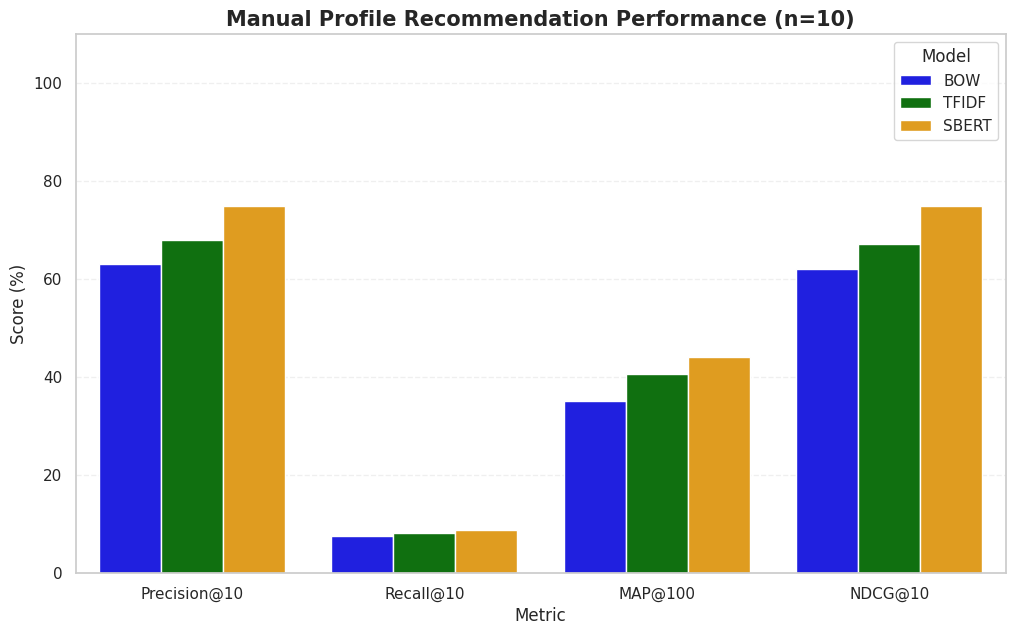

In [33]:
import difflib

manual_profiles = [
    {"user_id": 1, "name": "User 1", "job title": "Delivery Driver", "skill": "driving, motorbike, city knowledge", "preferenced_location": "Phnom Penh", "preferennce_category": "Logistics & Transport", "experience_years": 2},
    {"user_id": 2, "name": "User 2", "job title": "Security Guard", "skill": "security, honesty, hardworking", "preferenced_location": "Phnom Penh", "preferennce_category": "Security & Safety", "experience_years": 1},
    {"user_id": 3, "name": "User 3", "job title": "Software Developer", "skill": "Python, React, SQL", "preferenced_location": "Remote", "preferennce_category": "Technology & It", "experience_years": 3},
    {"user_id": 4, "name": "User 4", "job title": "Sales Assistant", "skill": "communication, customer service", "preferenced_location": "Phnom Penh", "preferennce_category": "Retail & Sales", "experience_years": 1},
    {"user_id": 5, "name": "User 5", "job title": "Waitress/Waiter", "skill": "English, food service", "preferenced_location": "Phnom Penh", "preferennce_category": "Hospitality & Tourism", "experience_years": 2},
    {"user_id": 6, "name": "User 6", "job title": "Accountant", "skill": "QuickBooks, Excel, tax, payroll", "preferenced_location": "Phnom Penh", "preferennce_category": "Accounting & Audit", "experience_years": 3},
    {"user_id": 7, "name": "User 7", "job title": "Construction Labor", "skill": "site clearing, heavy lifting", "preferenced_location": "Phnom Penh", "preferennce_category": "Construction & Engineering", "experience_years": 2},
    {"user_id": 8, "name": "User 8", "job title": "Hotel Receptionist", "skill": "English, Chinese, reception", "preferenced_location": "Phnom Penh", "preferennce_category": "Hospitality & Tourism", "experience_years": 1},
    {"user_id": 9, "name": "User 9", "job title": "Cleaner", "skill": "cleaning, punctual, tidy", "preferenced_location": "Phnom Penh", "preferennce_category": "Hospitality & Tourism", "experience_years": 2},
    {"user_id": 10, "name": "User 10", "job title": "Admin Assistant", "skill": "typing, filing, office management", "preferenced_location": "Phnom Penh", "preferennce_category": "Human Resources", "experience_years": 2}
]

def run_manual_study():
    print(f"{'PROFILE':<20} | {'MODEL':<8} | {'TOP 3 RECOMMENDATIONS (Score - Category)'}")
    print("-" * 110)
    
    instruction = "Represent this sentence for searching relevant passages: "
    hits = {'BoW': 0, 'TF-IDF': 0, 'SBERT': 0}

    for p in manual_profiles:
        query = f"I am a {p['job title']} in {p['preferenced_location']}. My skills are {p['skill']}. I have {p['experience_years']} years of experience."
        expected = p['preferennce_category'].lower()
        
        q_bow = bow_vectorizer.transform([query])
        s_bow = cosine_similarity(q_bow, bow_matrix).flatten()
        
        q_tfidf = tfidf_vectorizer.transform([query])
        s_tfidf = cosine_similarity(q_tfidf, tfidf_matrix).flatten()
        
        q_sbert = sbert_model.encode([instruction + query], show_progress_bar=False)
        s_sbert = cosine_similarity(q_sbert.reshape(1, -1), sbert_embeddings).flatten()
        
        models = [('BoW', s_bow), ('TF-IDF', s_tfidf), ('SBERT', s_sbert)]
        
        print(f"{p['job title']:<20} (Expected: {p['preferennce_category']})")
        for m_name, scores in models:
            top_idx = scores.argsort()[-3:][::-1]
            recs = []
            for i, idx in enumerate(top_idx):
                job = df_train.iloc[idx]
                if i == 0 and expected in job['category'].lower(): hits[m_name] += 1
                recs.append(f"{job['job_title']} ({scores[idx]:.2f} - {job['category']})")
            print(f"{'':<20} | {m_name:<8} | 1. {recs[0]}")
            print(f"{'':<20} | {'':<8} | 2. {recs[1]}")
            print(f"{'':<20} | {'':<8} | 3. {recs[2]}")
        print("-" * 110)
    
    print("SUMMARY: Category Match Accuracy")
    for m, count in hits.items():
        print(f"{m:<8}: {count}/{len(manual_profiles)} ({count/len(manual_profiles)*100:.1f}%)")

run_manual_study()

def calculate_manual_profile_metrics():
    results = {'bow': [], 'tfidf': [], 'sbert': []}
    instruction = "Represent this sentence for searching relevant passages: "
    actual_categories = df_train['category'].unique().tolist()

    for p in manual_profiles:
        query_text = f"Job Title: {p['job title']}. Skills: {p['skill']}"
        matches = difflib.get_close_matches(p['preferennce_category'], actual_categories, n=1, cutoff=0.0)
        target_category = matches[0] if matches else p['preferennce_category']

        relevant_mask = (df_train['category'] == target_category).values
        total_relevant = sum(relevant_mask)
        if total_relevant == 0: continue

        q_bow = bow_vectorizer.transform([query_text])
        q_tfidf = tfidf_vectorizer.transform([query_text])
        q_sbert = sbert_model.encode([instruction + query_text], show_progress_bar=False).reshape(1, -1)

        scores_dict = {
            'bow': cosine_similarity(q_bow, bow_matrix).flatten(),
            'tfidf': cosine_similarity(q_tfidf, tfidf_matrix).flatten(),
            'sbert': cosine_similarity(q_sbert, sbert_embeddings).flatten()
        }

        for model, scores in scores_dict.items():
            sorted_indices = scores.argsort()[::-1]
            top_idx = sorted_indices[:10]
            is_relevant_top_10 = relevant_mask[top_idx]

            p10 = sum(is_relevant_top_10) / 10
            r10 = sum(is_relevant_top_10) / total_relevant

            is_relevant_top_100 = relevant_mask[sorted_indices[:100]]
            map_val = calculate_map_cat(is_relevant_top_100, total_relevant)
            ndcg10 = calculate_ndcg_cat(is_relevant_top_10, total_relevant, k=10)

            results[model].append([p10, r10, map_val, ndcg10])

    return results

manual_results = calculate_manual_profile_metrics()

manual_profile_metrics = []
for model in ['bow', 'tfidf', 'sbert']:
    m = np.mean(manual_results[model], axis=0)
    manual_profile_metrics.append({'Model': model.upper(), 'Metric': 'Precision@10', 'Score (%)': m[0] * 100})
    manual_profile_metrics.append({'Model': model.upper(), 'Metric': 'Recall@10',    'Score (%)': m[1] * 100})
    manual_profile_metrics.append({'Model': model.upper(), 'Metric': 'MAP@100',      'Score (%)': m[2] * 100})
    manual_profile_metrics.append({'Model': model.upper(), 'Metric': 'NDCG@10',      'Score (%)': m[3] * 100})

plt.figure(figsize=(12, 7))
sns.barplot(data=pd.DataFrame(manual_profile_metrics), x='Metric', y='Score (%)', hue='Model', palette={'BOW': 'blue', 'TFIDF': 'green', 'SBERT': 'orange'})
plt.title('Manual Profile Recommendation Performance (n=10)', fontsize=15, fontweight='bold')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()